# <span style="color:#990000;">AAN 525 Week 1 Assignment: Preparing and Exploring Data</span>

## Overview

A financial institution faces an increase in loan defaults and wants to mitigate risks by improving its loan approval process. The goal is to develop a data-driven strategy by analyzing historical loan data to identify key factors that predict defaults. This will allow the institution to refine its credit policies and make more informed lending decisions, minimizing losses and improving profitability.

A strong model is needed to predict the likelihood of loan default and avoid applications prone to default. The model’s performance will directly impact the financial institution's bottom line.  Your job is to build a model to analyze historical loan data to identify key factors that predict defaults. 

This is the first part of a three-part assignment. This week, you will prepare the data and conduct exploratory data analysis. 

**Lecture Notebook**

The *Week 1 Lecture Notebook* provided in Canvas will provide additional guidance for completing the assignment. You are also encouraged to look at other notebooks for additional help.

## Instructions
To complete this assignment, follow these steps:
### Import

In [5]:
# data
import pandas as pd
import numpy as np

# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#import missingno as msno
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
#from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

# styling
%matplotlib inline
sns.set_style('darkgrid')
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'

import os 
#from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

### Load Data
Use pandas to read the data and create a DataFrame.

In [6]:
#Provide code to load the dataset here.
path = '../data'
data =  pd.read_csv(path + "/aan525_w1a_data.csv") 
data.head()  

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Data Dictionary
This data dictionary provides a list of the variables (features) in the DataFrame and defines them.
- **loan_status**: This is the target variable, where 0 indicates non-default and 1 indicates default.
    - 0: Non-default - The borrower successfully repaid the loan as agreed, and there was no default.
    - 1: Default - The borrower failed to repay the loan according to the agreed-upon terms and defaulted on the loan.
- **person_age**: Age of the individual applying for the loan.
- **person_income**: Annual income of the individual.
- **person_home_ownership**: Type of home ownership of the individual.
    - rent: The individual is currently renting a property.
    - mortgage: The individual has a mortgage on the property they own.
    - own: The individual owns their home outright.
    - other: Other categories of home ownership that may be specific to the dataset.
- **person_emp_length**: Employment length of the individual in years.
- **loan_intent**: The intent behind the loan application.
- **loan_grade**: The grade assigned to the loan based on the creditworthiness of the borrower.
    - A: The borrower has a high creditworthiness, indicating low risk.
    - B: The borrower is relatively low-risk, but not as creditworthy as Grade A.
    - C: The borrower's creditworthiness is moderate.
    - D: The borrower is considered to have higher risk compared to previous grades.
    - E: The borrower's creditworthiness is lower, indicating a higher risk.
    - F: The borrower poses a significant credit risk.
    - G: The borrower's creditworthiness is the lowest, signifying the highest risk.
- **loan_amnt**: The loan amount requested by the individual.
- **loan_int_rate**: The interest rate associated with the loan.
- **loan_percent_income**: The percentage of income represented by the loan amount.
- **cb_person_default_on_file**: Historical default of the individual as per credit bureau records.
    - Y: The individual has a history of defaults on their credit file.
    - N: The individual does not have any history of defaults.
- **cb_person_cred_hist_length**: The length of the individual's credit history.

In [7]:
cat_var = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']
num_var = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']  
X_vars = cat_var + num_var
target='loan_status'

### Data Inspection
To understand your data, inspect the first few rows and explore the dataset structure.
- How many records and columns are there?
- What are the categorical and numerical fields?

In [14]:
# Provide the code to inspect and understand the data here.
#Numerical Variables
num_var
#Categorical Variables
cat_var
#Target Variable
target
#Dataset summary
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [15]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


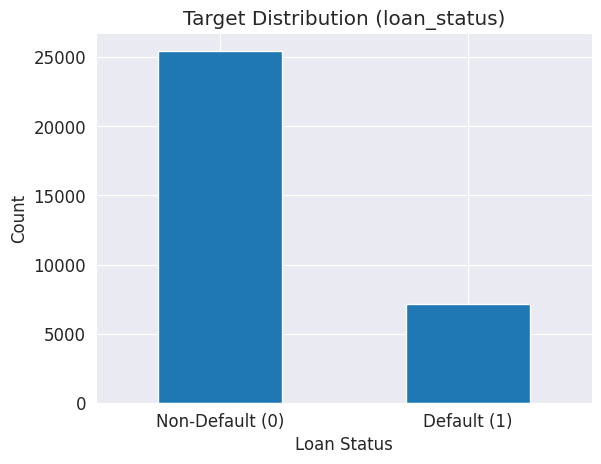

In [18]:
# Understand the target distribution
print(data[target].value_counts())
print(data[target].value_counts(normalize=True) * 100)  # percentage

data[target].value_counts().plot(kind='bar')
plt.title('Target Distribution (loan_status)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Default (0)', 'Default (1)'], rotation=0)
plt.show()

### Data Cleaning
- Identify and address inconsistencies or data entry errors. 
- Check for duplicate records and remove them as needed.
- Note your findings in a Markdown cell.


In [20]:
# Check for any duplications
print("Number of duplicated:",data.duplicated().sum())

Number of duplicated: 165


In [21]:
#Viewing the duplicated rows
data[data.duplicated()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15975,23,42000,RENT,5.0,VENTURE,B,6000,9.99,0,0.14,N,4
15989,23,90000,MORTGAGE,7.0,EDUCATION,B,8000,10.36,0,0.09,N,3
15995,24,48000,MORTGAGE,4.0,MEDICAL,A,4000,5.42,0,0.08,N,4
16025,24,10000,RENT,8.0,PERSONAL,A,3000,7.90,1,0.30,N,3
16028,23,100000,MORTGAGE,7.0,EDUCATION,A,15000,7.88,0,0.15,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32010,42,39996,MORTGAGE,2.0,HOMEIMPROVEMENT,A,2500,5.42,0,0.06,N,12
32047,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0,0.08,N,17
32172,49,120000,MORTGAGE,12.0,MEDICAL,B,12000,10.99,0,0.10,N,12
32259,39,40000,OWN,4.0,VENTURE,B,1000,10.37,0,0.03,N,16


165 duplicated rows are present.

In [28]:
# Remove duplicates
data = data.drop_duplicates()

In [32]:
#After duplication
data.shape

(32416, 12)

In [33]:
# Check for any duplications after removal
print("Number of duplicated:",data.duplicated().sum())

Number of duplicated: 0


In [30]:
#Viewing the table after removal
print("Shape after duplicate removal", data.shape) 
#Table top four rows
data.head()

Shape after duplicate removal (32416, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [37]:
# Check for the number of unique records
data.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

In [44]:
# view unique values for categorical columns
for col in cat_var:
    print(f"{col}: {data[col].unique()}")

person_home_ownership: <ArrowStringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str
loan_intent: <ArrowStringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str
loan_grade: <ArrowStringArray>
['D', 'B', 'C', 'A', 'E', 'F', 'G']
Length: 7, dtype: str
cb_person_default_on_file: <ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str


In [36]:
# Check the count of missing records for each variable
print("Null:",data.isnull().sum())

Null: person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [46]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,31529.00000,32416.000000,29321.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.79051,9593.845632,11.017265,0.218688,0.170250,5.811297
std,6.354100,6.201558e+04,4.14549,6322.730241,3.241680,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.00000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.00000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.00000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.00000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [47]:
# include categorical columns as well
data.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,32416,31529.00000,32416,32416,32416.000000,29321.000000,32416.000000,32416.000000,32416,32416.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16378,NaN,6411,10703,NaN,NaN,NaN,NaN,26686,NaN
mean,27.747008,6.609164e+04,NaN,4.79051,NaN,NaN,9593.845632,11.017265,0.218688,0.170250,NaN,5.811297
std,6.354100,6.201558e+04,NaN,4.14549,NaN,NaN,6322.730241,3.241680,0.413363,0.106812,NaN,4.059030
min,20.000000,4.000000e+03,NaN,0.00000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.854200e+04,NaN,2.00000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.00000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.921800e+04,NaN,7.00000,NaN,NaN,12250.000000,13.470000,0.000000,0.230000,NaN,8.000000


### Split the Data
Split the data into training and testing sets.

In [50]:
# Perform the train and test split
X=data.drop(columns=[target])
y=data[target]
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (25932, 11)
X_test shape: (6484, 11)
y_train shape: (25932,)
y_test shape: (6484,)


In [75]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,31529.00000,32416.000000,29321.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.79051,9593.845632,11.017265,0.218688,0.170250,5.811297
std,6.354100,6.201558e+04,4.14549,6322.730241,3.241680,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.00000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.00000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.00000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.00000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Exploratory Data Analysis with Data Visualizations

#### Univariate Analysis (The Distribution of X)
- Visualize the distribution of key variables. Create histograms to understand feature distributions and outliers.
- Comment on distributions, skewness, and outliers in a Markdown cell.

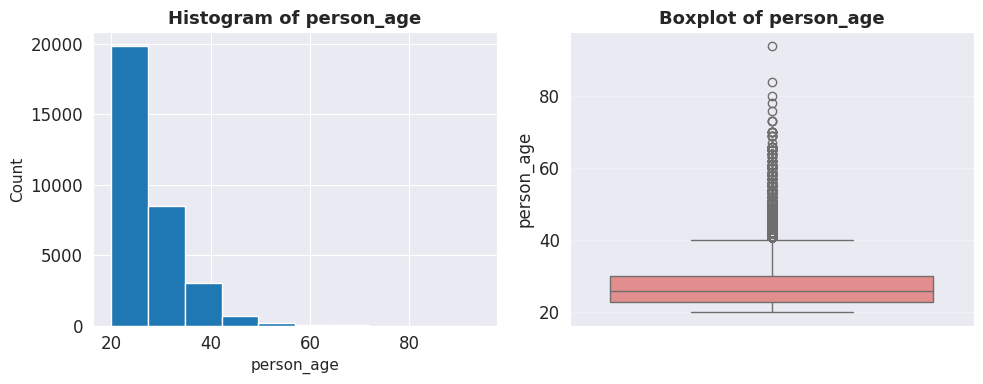

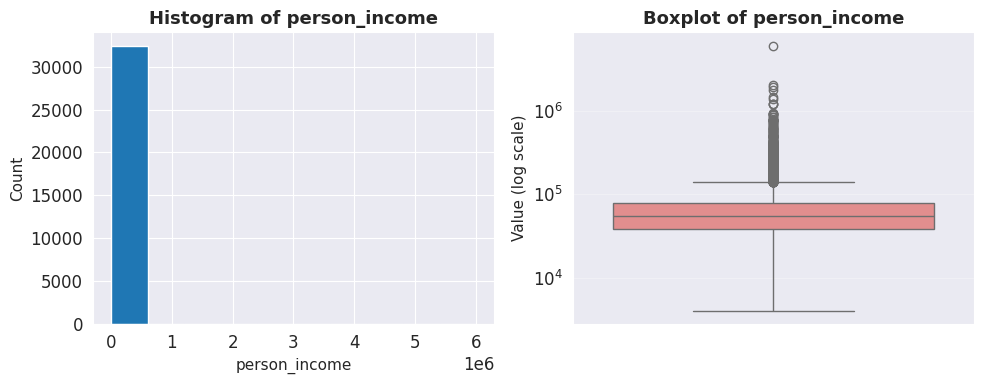

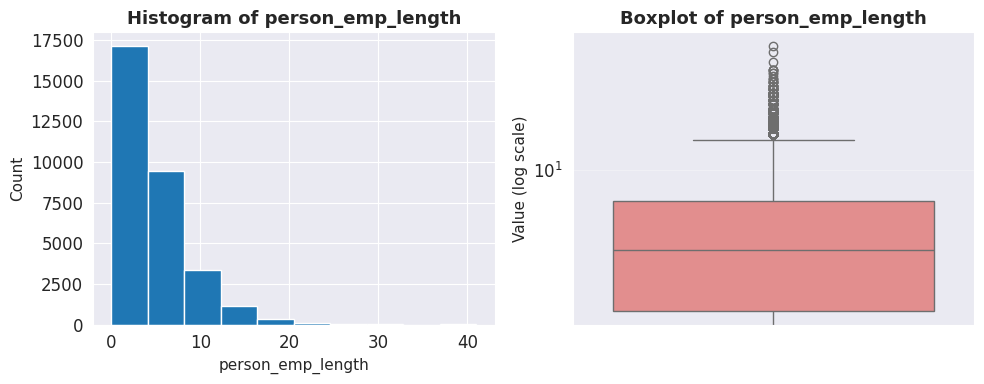

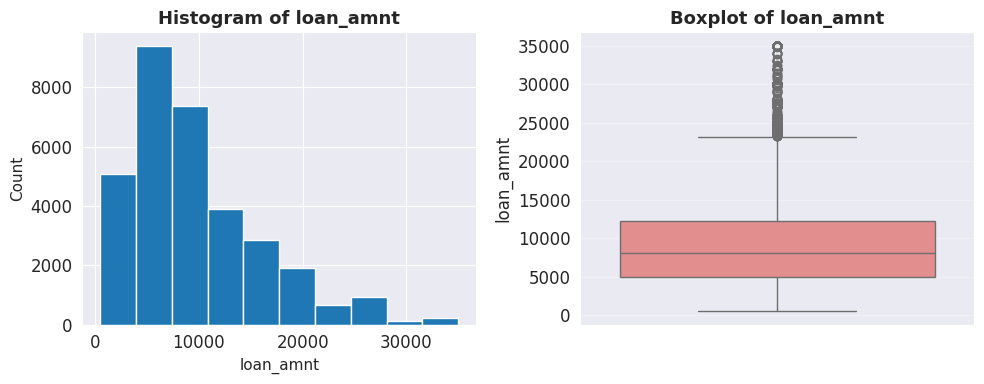

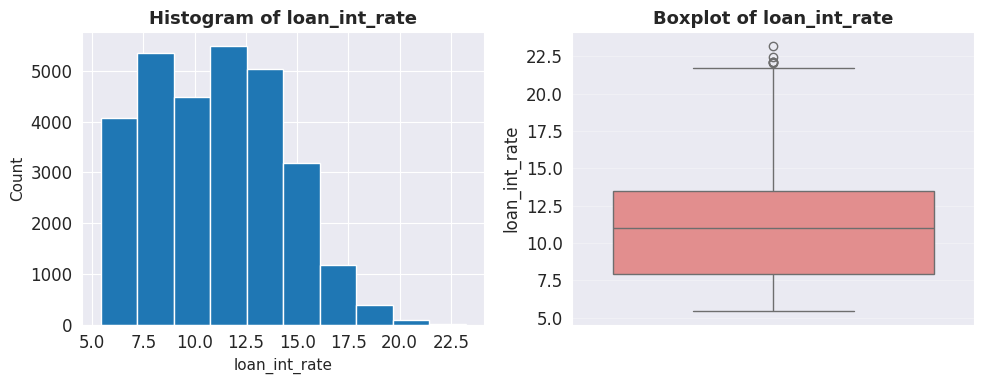

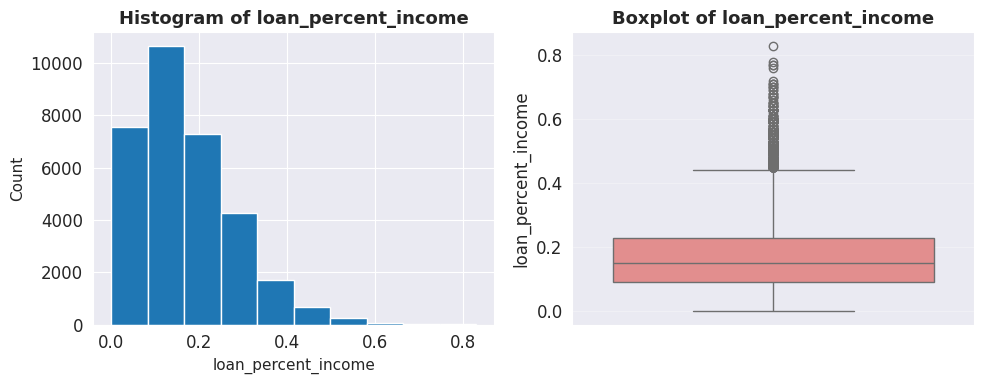

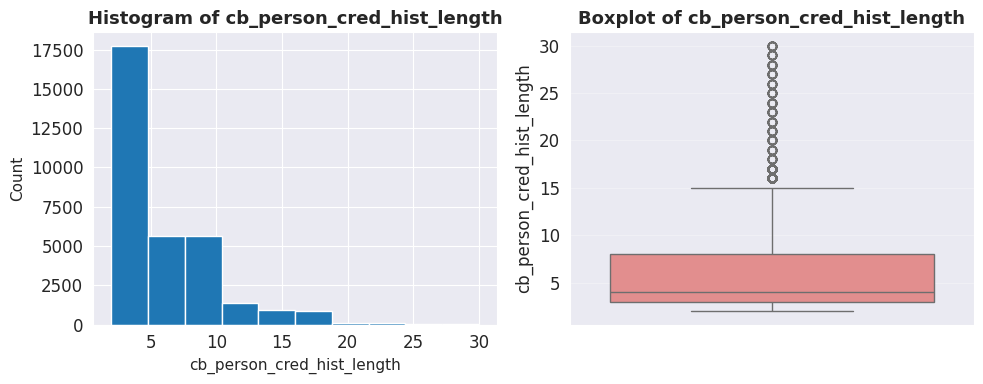

Max age after fix: 94.0
Max emp_length after fix: 41.0


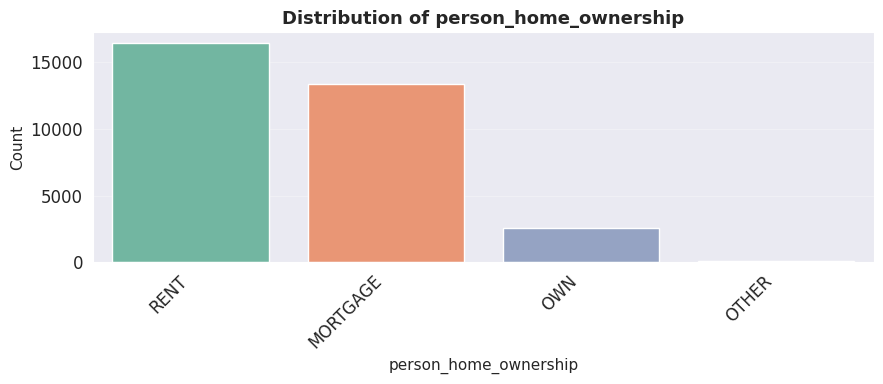

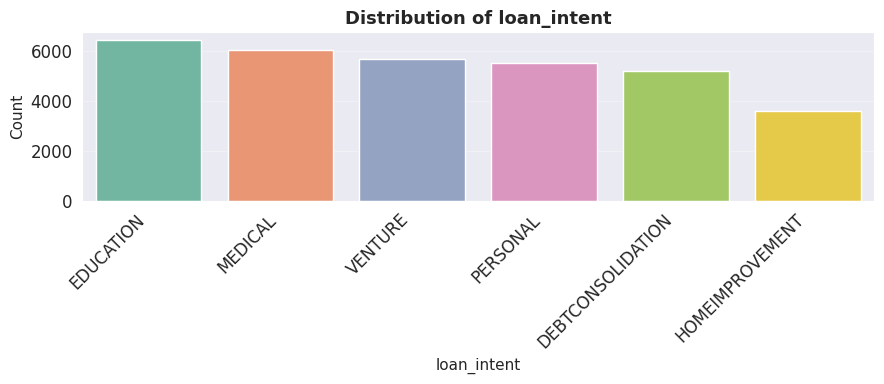

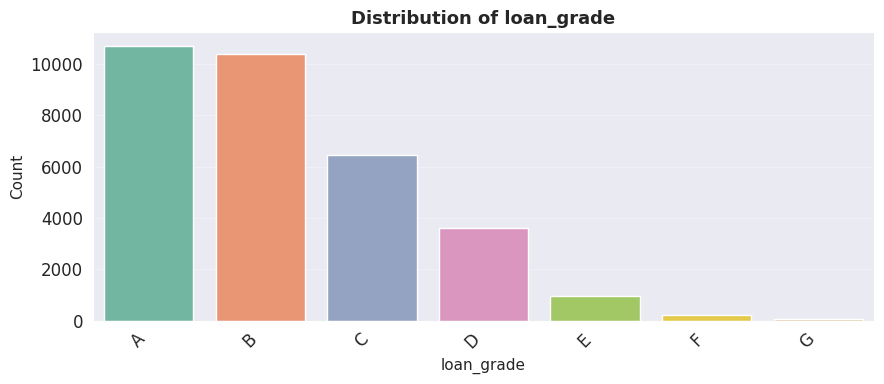

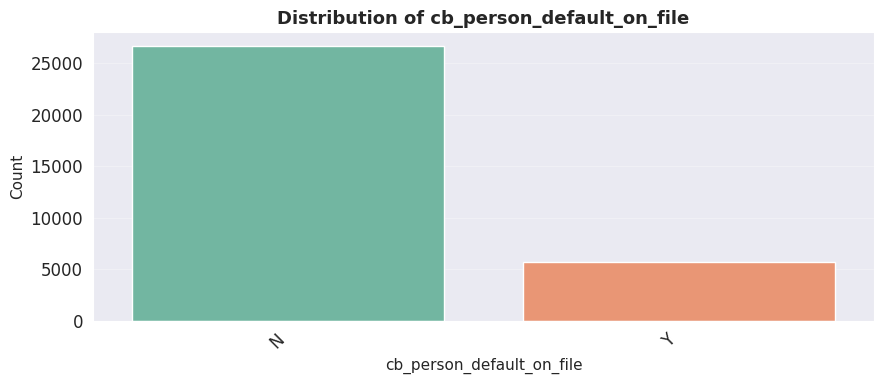

In [77]:
# Show the distribution of the variables in the above X_vars
import seaborn as sns

# Numerical columns
for col in num_var:
    plt.figure(figsize=(10, 4))
    
    # Histogram
    plt.subplot(1, 2, 1)
    data[col].hist()
    plt.title(f'Histogram of {col}', fontsize=13, fontweight='bold')
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Count', fontsize=11)
    
    # Boxplot
    plt.subplot(1, 2, 2)
    if col in ['person_income', 'person_emp_length']:
        sns.boxplot(y=data[col], color='lightcoral')
        plt.title(f'Boxplot of {col}', fontsize=13, fontweight='bold')
        plt.grid(axis='y', alpha=0.3)
        # format y-axis to readable numbers
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        plt.yscale('log')  # log scale for skewed data
        plt.ylabel('Value (log scale)', fontsize=11)
    else:
        sns.boxplot(y=data[col], color='lightcoral')
        plt.title(f'Boxplot of {col}', fontsize=13, fontweight='bold')
        plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
# ── Fix outliers ─────────────────────────────────────────────────

# person_age - replace anything over 100 with median age
age_median = data['person_age'].median()
data['person_age'] = data['person_age'].apply(lambda x: age_median if x > 100 else x)

# person_emp_length - replace anything over 60 with median emp length
emp_median = data['person_emp_length'].median()
data['person_emp_length'] = data['person_emp_length'].apply(lambda x: emp_median if x > 60 else x)

# confirm fix
print("Max age after fix:", data['person_age'].max())
print("Max emp_length after fix:", data['person_emp_length'].max())

# Categorical columns
for col in cat_var:
    plt.figure(figsize=(9, 4))
    
    counts = data[col].value_counts()
    colors = sns.color_palette('Set2', len(counts))
    
    sns.barplot(x=counts.index, y=counts.values, palette=colors)
    plt.title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Count', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

- Loan Intent: Education accounts for the highest proportion of loan applications, while home improvement represents the lowest intent among borrowers. Notably, the distribution across all loan intent categories is relatively balanced, with no single category dramatically outweighing the others.
- Loan Grade: Grade A and B borrowers make up the largest share of applicants and are closely distributed, indicating that the majority of borrowers have relatively good creditworthiness.
- Loan Status: The dataset is imbalanced, with the majority of borrowers not in default. Approximately 25,000 borrowers successfully repaid their loans while around 7,000 borrowers defaulted.
- Home Ownership: The largest segment of borrowers are renters, suggesting that most applicants do not own property.
- Credit History Length: Most borrowers have a shorter credit history of under 5 years, which may indicate a younger borrower demographic or limited credit experience.
- Loan Percent Income: The most common loan percent income is approximately 0.1, meaning the loan amount represents around 10% of a borrower's annual income. This suggests that most borrowers are taking on loans that are relatively manageable relative to their income level.


- person_age: Right skewed with most borrowers concentrated around 20 years old. 
- Person_income: Extremely right skewed. The histogram shows a single tall bar containing virtually all 32,000+ borrowers within the $0-$500,000 income range. This extreme skew makes the histogram appear as one bar with nothing else visible.
- Person_emp_length: Right skewed with most borrowers having 0-7 years of employment. 
- loan_amnt: Slight right skew with most loans falling between $5,000-$12,250.
- loan_int_rate: Approximately normally distributed with mean and median both near 11%, ranging from 5.4%-23.2%. No extreme outliers detected.
- Loan_percent_income: Right skewed. The histogram shows the highest concentration of borrowers between 0.1-0.2 (10%-20% of income), with around 10,000 borrowers in that range. 
- cb_person_cred_hist_length: Right skewed with most borrowers having a credit history of 5 years or less


#### Multivariate Analysis (The Relationships Among Xs): Heatmap
- Use a heatmap to detect multicollinearity and key patterns.
- Explain what a heatmap does and provide any insights from your heatmap in a Markdown cell.

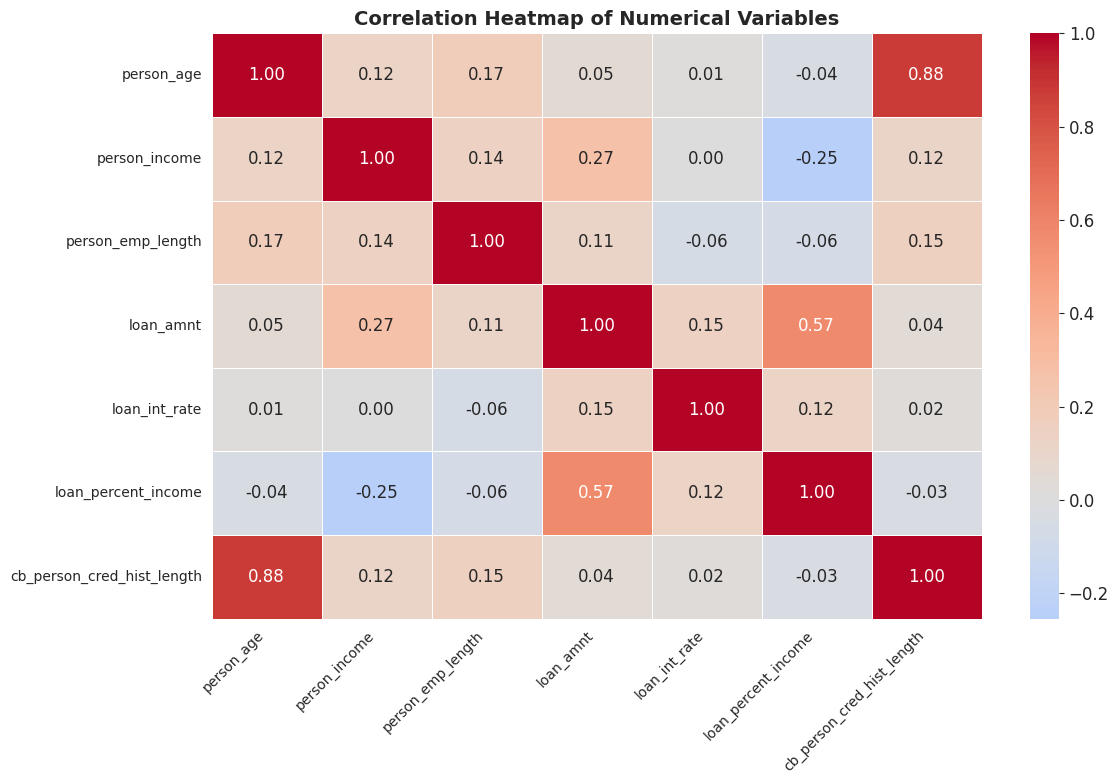

In [78]:
# Provide the code for a heatmap for the variables in num_var
plt.figure(figsize=(12, 8))

sns.heatmap(data[num_var].corr(), 
            annot=True,          # show correlation values
            fmt='.2f',           # round to 2 decimal places
            cmap='coolwarm',     # color scheme
            center=0,            # center color at 0
            linewidths=0.5,      # grid lines between cells
            linecolor='white')

plt.title('Correlation Heatmap of Numerical Variables', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

- Self-correlation: All variables show a perfect correlation of 1.00 with themselves along the diagonal, which is expected and confirms the heatmap is reading correctly.
  
- person_age & cb_person_cred_hist_length (0.88): The strongest correlation in the dataset. This is a very strong positive relationship, meaning older borrowers tend to have a longer credit history, which is logical as credit history naturally accumulates over time with age.
  
- loan_amount & loan_percent_income (0.57): A moderate to strong positive relationship, indicating that borrowers who take out larger loans tend to have a higher loan burden relative to their income. This is an important relationship to be aware of as it may introduce multicollinearity in modelling.

  
- person_income & loan_percent_income (-0.25): A weak negative relationship, meaning borrowers with higher incomes tend to have a lower loan burden relative to their income. This makes logical sense as higher earners can absorb larger loans without it representing a significant portion of their income.

  
- person_emp_length & loan_percent_income (-0.06): A very weak negative relationship, suggesting that longer employed borrowers tend to have a slightly lower loan burden relative to income, however the relationship is negligible.

  
- person_age & loan_percent_income (-0.04): A negligible negative relationship, indicating that age has virtually no meaningful impact on the proportion of income a borrower allocates to their loan.

#### Multivariate Analysis (The Relationships Among Xs): Pair Plot
- Use a pair plot to detect multicollinearity and key patterns.
- In a Markdown cell, explain what a pair plot does and provide any insights from your pair plot.

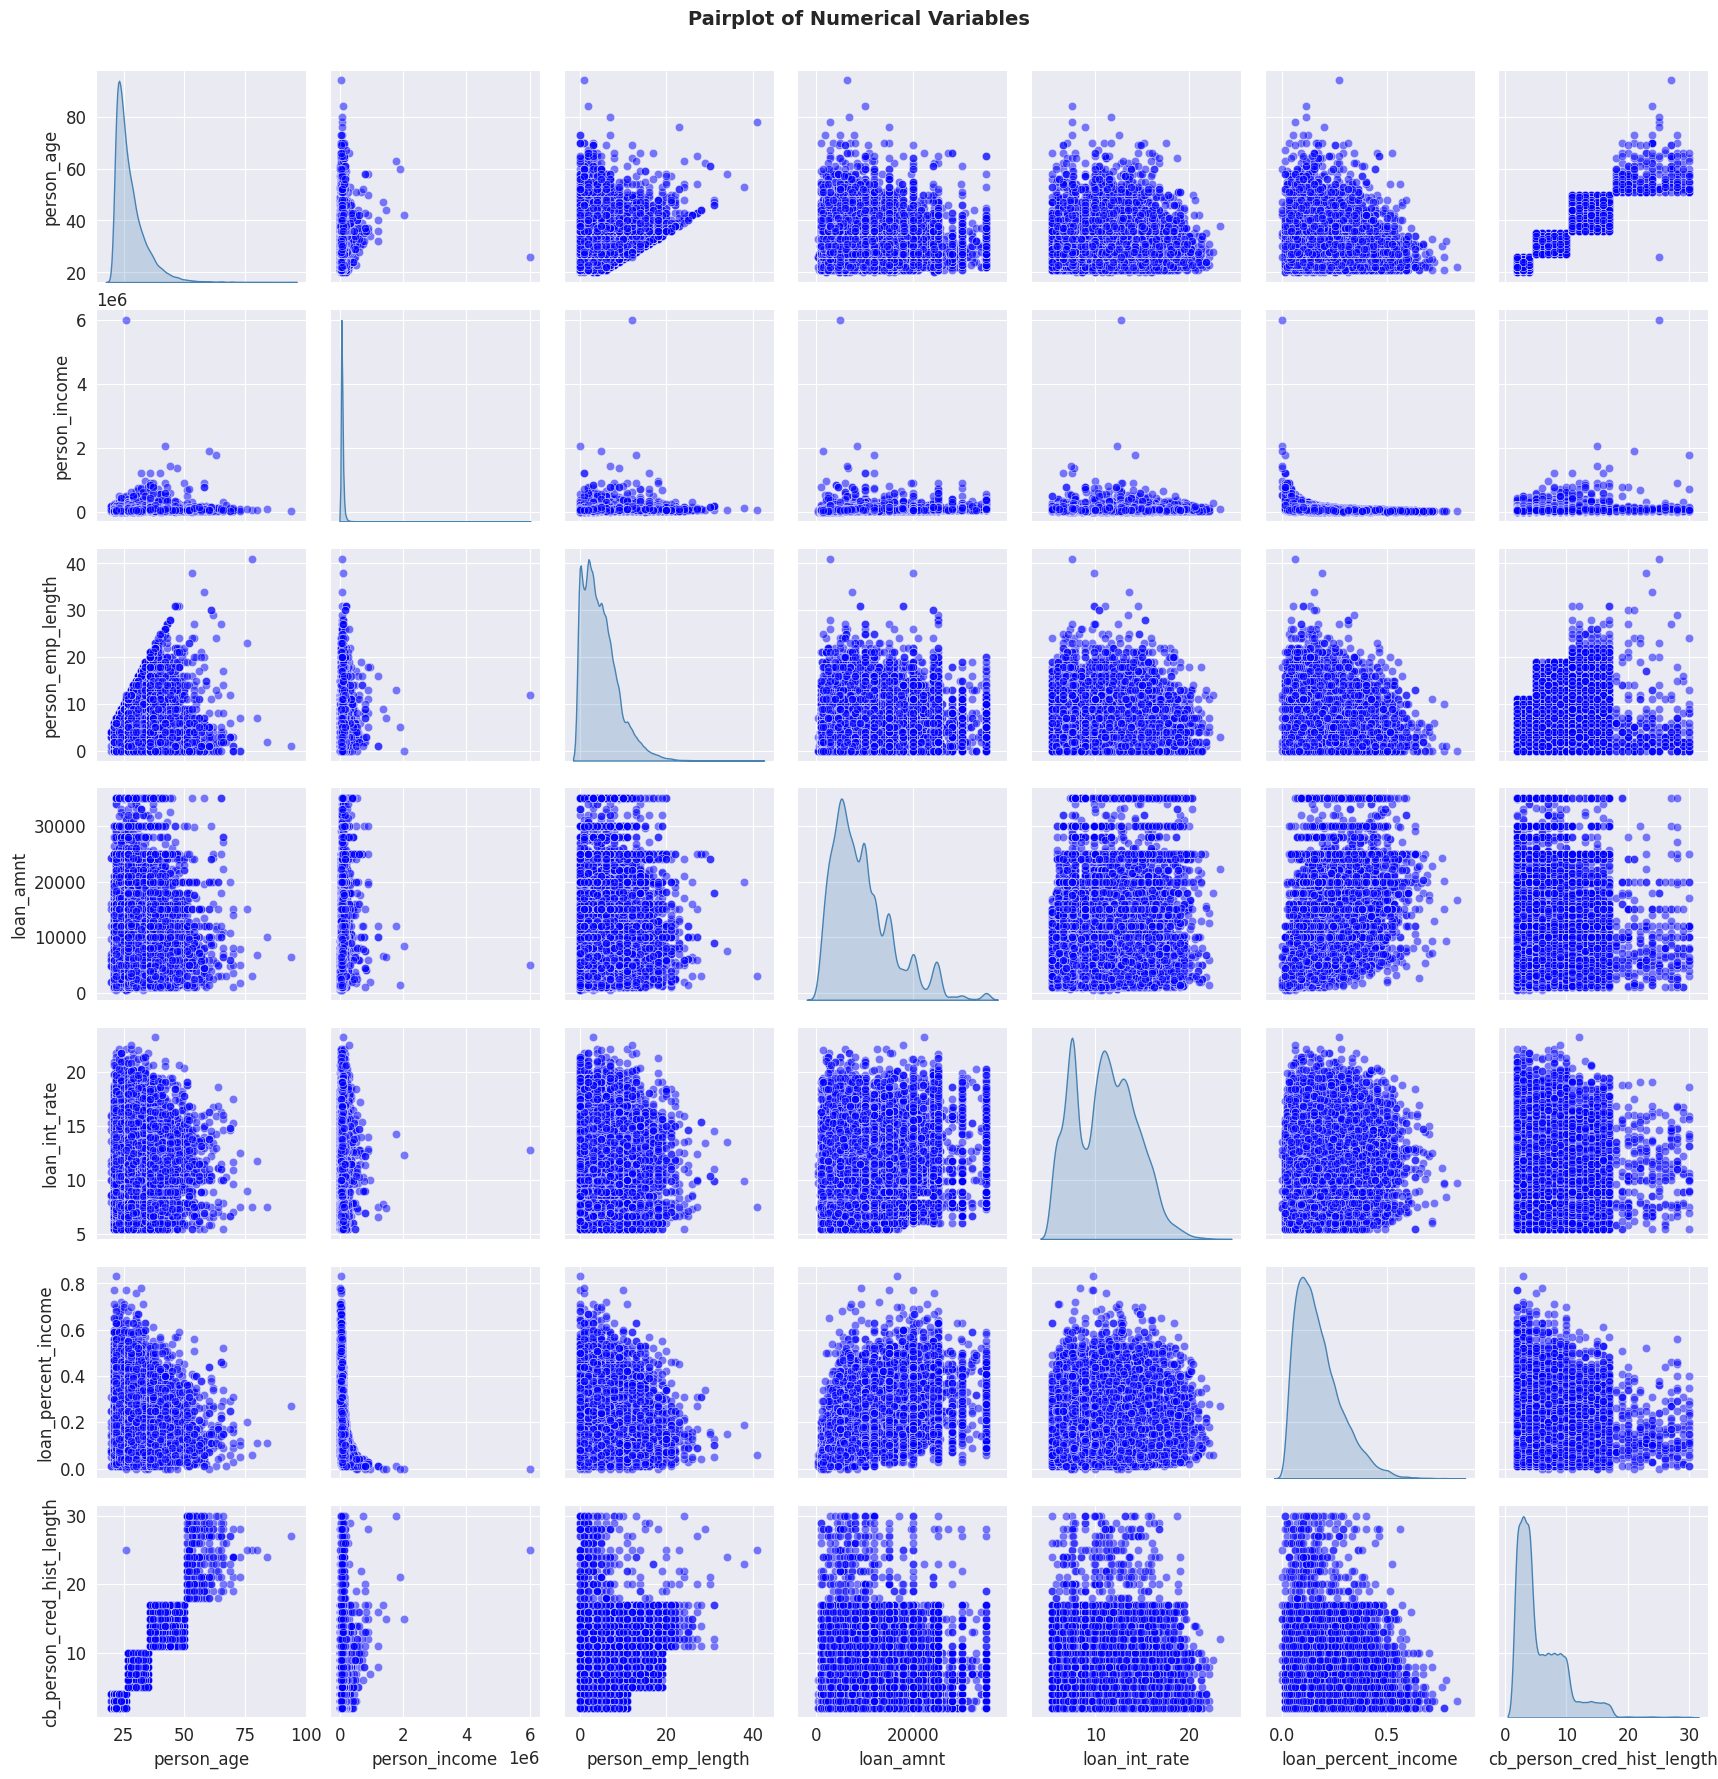

In [79]:
# Provide the code for a pair plot for the variables in X_variables
sns.pairplot(data[num_var], 
             diag_kind='kde',      # density curve on diagonal
             plot_kws={'alpha': 0.5, 'color': 'blue'},  # transparency for overlapping points
             diag_kws={'color': 'steelblue'})

plt.suptitle('Pairplot of Numerical Variables', fontsize=14, fontweight='bold', y=1.02)
plt.show()

*Enter Markdown response here:*

#### Bivariate Analysis (The Relationships With X and Y) for Categorical Variables
Analyze the relationship between individual features and the target variable.
- Explain what a bivariate analysis does in a Markdown cell. 

<Figure size 900x400 with 0 Axes>

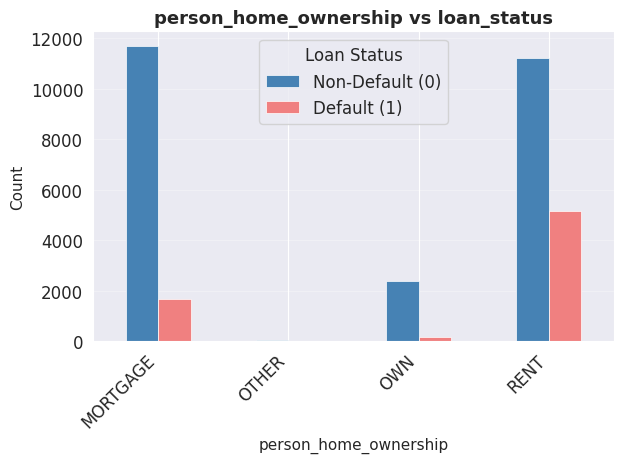

<Figure size 900x400 with 0 Axes>

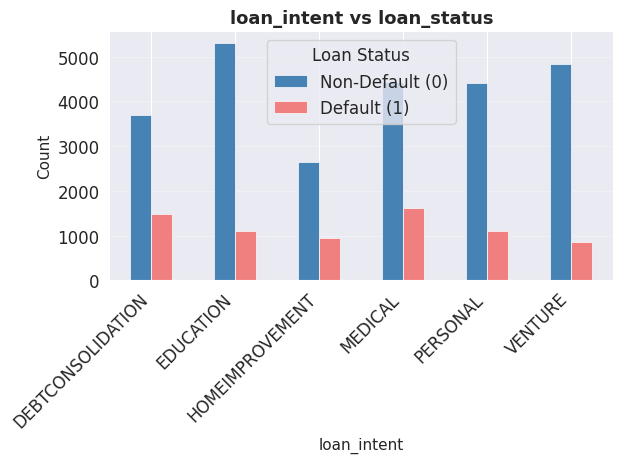

<Figure size 900x400 with 0 Axes>

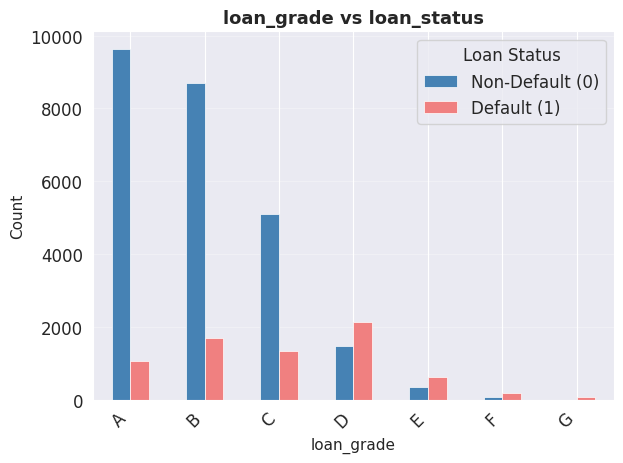

<Figure size 900x400 with 0 Axes>

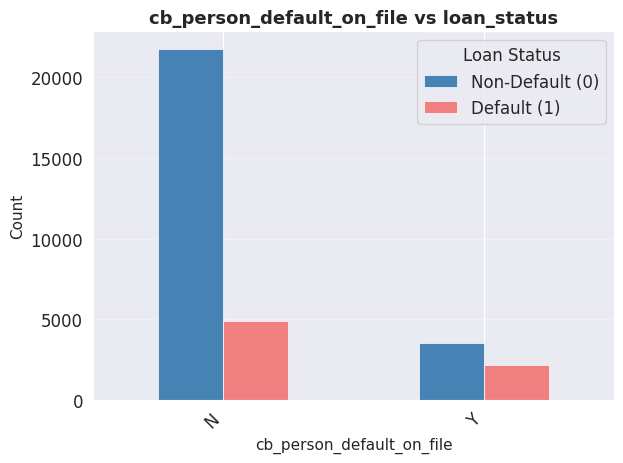

In [80]:
# Provide the code 
for col in cat_var:
    plt.figure(figsize=(9, 4))
    
    counts = data.groupby([col, target]).size().unstack()
    counts.plot(kind='bar', 
                color=['steelblue', 'lightcoral'],  # 0=steelblue, 1=lightcoral
                edgecolor='white',
                linewidth=0.5)
    
    plt.title(f'{col} vs {target}', fontsize=13, fontweight='bold')
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Count', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.legend(['Non-Default (0)', 'Default (1)'], title='Loan Status')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

- loan_grade vs loan_status: Borrowers with Grade A, B and C show significantly higher non-defaults at approximately 9,500, 8,500 and 5,000 respectively, indicating that higher creditworthiness is strongly associated with successful loan repayment. From Grade D onwards the trend reverses with defaults beginning to outnumber non-defaults, confirming that lower grade borrowers carry significantly higher risk. Grade G shows almost no non-defaults at all, representing the highest risk segment in the dataset.
- loan_intent vs loan_status: Education leads with the highest number of non-defaulting borrowers at approximately 5,000, while home improvement has the lowest non-default count at around 2,500. Medical loans show the highest default count at approximately 1,500, suggesting that medical borrowers may face greater financial difficulty in meeting repayments. The distribution of non-defaults across the remaining categories is relatively even.
- person_home_ownership vs loan_status: Mortgage holders and renters dominate the non-default category at approximately 11,500 and 11,000 respectively. However renters show a significantly higher default count at approximately 5,000 compared to mortgage holders at around 1,500, suggesting renters carry a higher default risk despite their large non-default numbers. Borrowers who own their home outright show approximately 2,500 non-defaults with very few defaults, making them the most reliable segment proportionally.
- cb_person_default_on_file vs loan_status: Borrowers with no prior default on file (N) dominate with approximately 22,000 non-defaults and 5,000 defaults. Borrowers with a prior default on file (Y) show approximately 3,500 non-defaults and 2,000 defaults, meaning that despite having fewer borrowers overall, the proportion of defaults is noticeably higher among those with a prior default history. This suggests that historical default behaviour is a strong indicator of future default risk.

#### Bin a Continuous Variable in "num_var" to Categorical for Visualization
Bin a continuous variable in "num_var" to a categorical variable.

In a Markdown cell:
- Explain why you would want to bin a continuous variable to show it as a categorical variable.
- Explain pd.qcut().

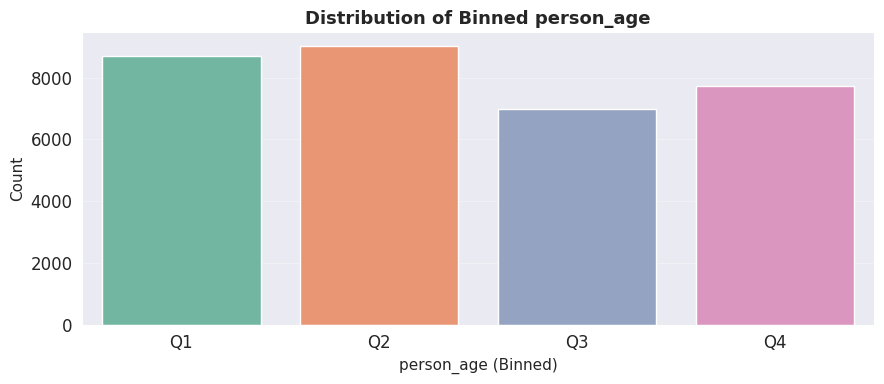

In [82]:
# Provide the code
col_to_bin = 'person_age'  # change to any column in num_var

# Bin using pd.qcut() - equal frequency binning
data[f'{col_to_bin}_binned'] = pd.qcut(data[col_to_bin], 
                                        q=4,                                        # number of bins
                                        labels=['Q1', 'Q2', 'Q3', 'Q4'])           # bin labels

# Plot the binned variable
plt.figure(figsize=(9, 4))

counts = data[f'{col_to_bin}_binned'].value_counts().sort_index()
colors = sns.color_palette('Set2', len(counts))

sns.barplot(x=counts.index, y=counts.values, palette=colors)
plt.title(f'Distribution of Binned {col_to_bin}', fontsize=13, fontweight='bold')
plt.xlabel(f'{col_to_bin} (Binned)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Age is a continuous variable so we use pd.qcut() to bin it into 4 equal sized groups, making it easier to compare against loan status and identify patterns across age ranges. Q2 (ages 23–26) has the highest borrowers at approximately 9,000, followed by Q1 (ages 20–23) at 8,500, Q4 (ages 30+) at 7,500 and Q3 (ages 26–30) being the lowest at around 7,000. The distribution is relatively even across all groups, suggesting age alone may not be a strong differentiating factor in determining whether a borrower defaults.

#### Bivariate Analysis (The Relationships of X and Y) for Continuous Variables

Create a "for loop" that generates categorical variables "_D" for the continuous variables.


Bin ranges for person_age:
  Q1: 20.0 - 23.0
  Q2: 23.0 - 26.0
  Q3: 26.0 - 30.0
  Q4: 30.0 - 144.0


<Figure size 900x400 with 0 Axes>

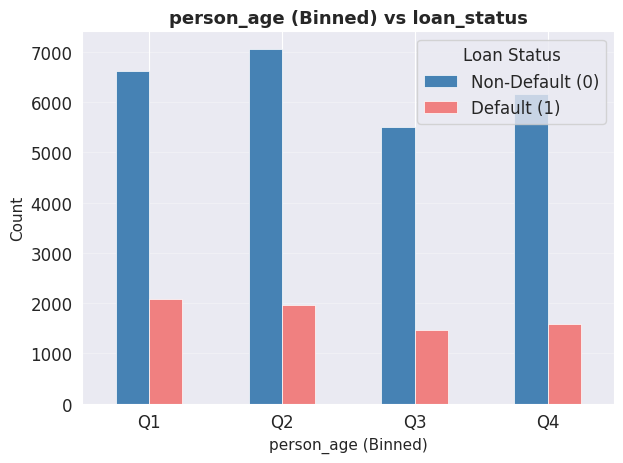


Bin ranges for person_income:
  Q1: 4000.0 - 38542.0
  Q2: 38542.0 - 55000.0
  Q3: 55000.0 - 79218.0
  Q4: 79218.0 - 6000000.0


<Figure size 900x400 with 0 Axes>

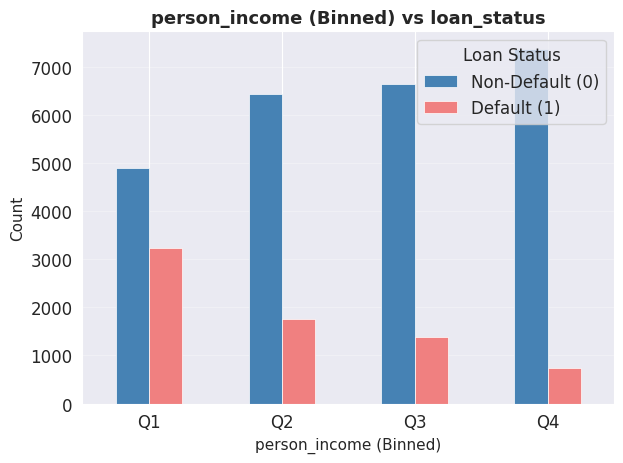


Bin ranges for person_emp_length:
  Q1: 0.0 - 2.0
  Q2: 2.0 - 4.0
  Q3: 4.0 - 7.0
  Q4: 7.0 - 123.0


<Figure size 900x400 with 0 Axes>

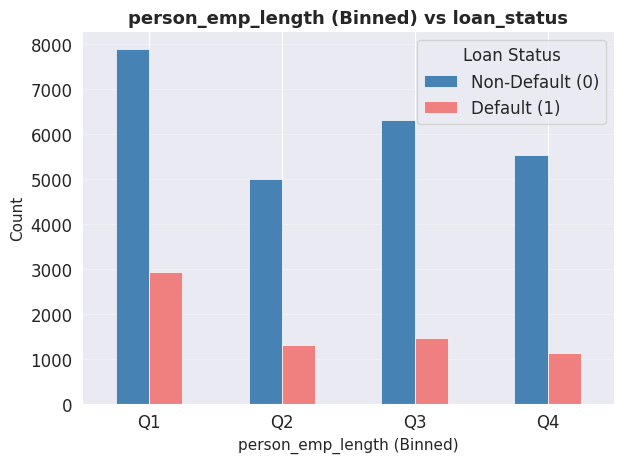


Bin ranges for loan_amnt:
  Q1: 500.0 - 5000.0
  Q2: 5000.0 - 8000.0
  Q3: 8000.0 - 12250.0
  Q4: 12250.0 - 35000.0


<Figure size 900x400 with 0 Axes>

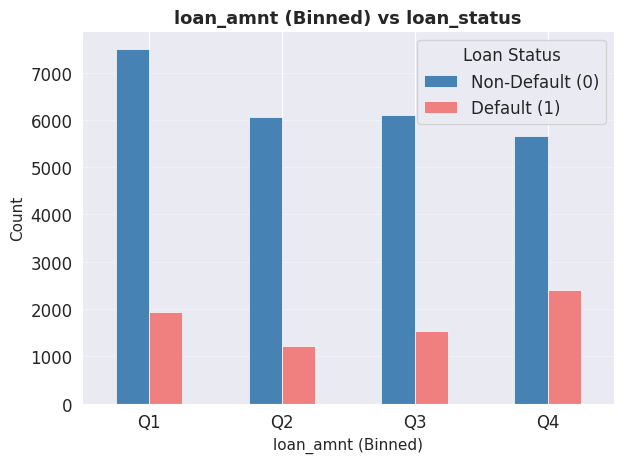


Bin ranges for loan_int_rate:
  Q1: 5.4 - 7.9
  Q2: 7.9 - 11.0
  Q3: 11.0 - 13.5
  Q4: 13.5 - 23.2


<Figure size 900x400 with 0 Axes>

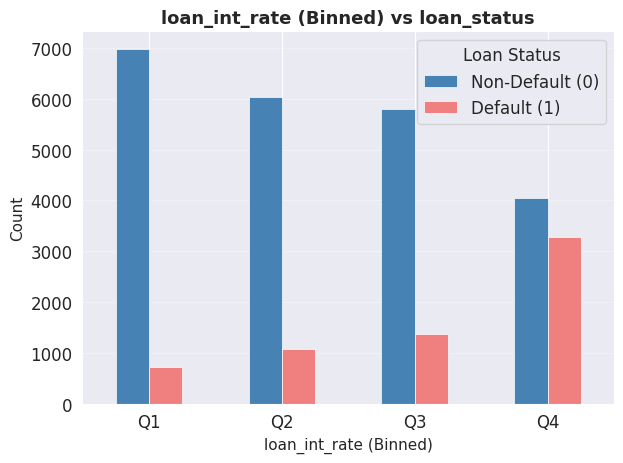


Bin ranges for loan_percent_income:
  Q1: 0.0 - 0.1
  Q2: 0.1 - 0.2
  Q3: 0.2 - 0.2
  Q4: 0.2 - 0.8


<Figure size 900x400 with 0 Axes>

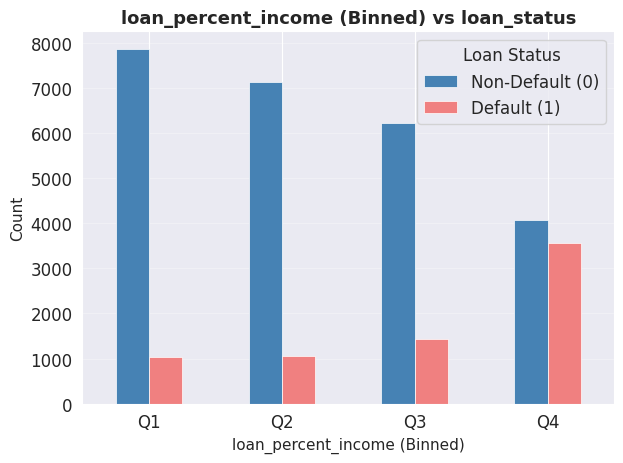


Bin ranges for cb_person_cred_hist_length:
  Q1: 2.0 - 3.0
  Q2: 3.0 - 4.0
  Q3: 4.0 - 8.0
  Q4: 8.0 - 30.0


<Figure size 900x400 with 0 Axes>

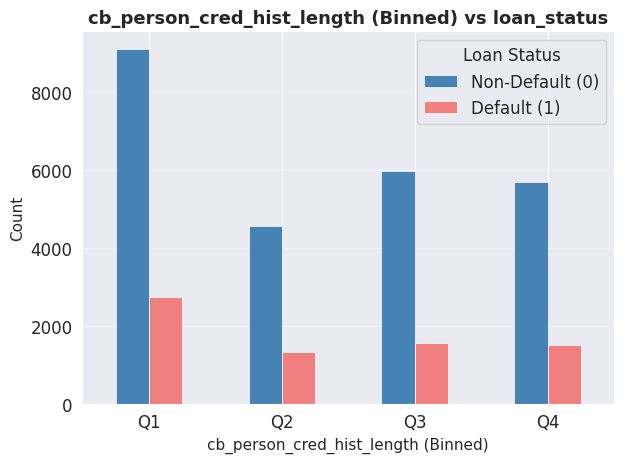

In [71]:
# Provide the code to do a for loop that creates categorical variables "_D" for the continuous variables
for col in num_var:
    # Create binned column
    col_D = col + '_D'
    data[col_D], bin_edges = pd.qcut(data[col], 
                                      q=4, 
                                      labels=['Q1', 'Q2', 'Q3', 'Q4'],
                                      retbins=True,
                                      duplicates='drop')
    
    # Print bin ranges
    print("\nBin ranges for " + col + ":")
    for i, label in enumerate(['Q1', 'Q2', 'Q3', 'Q4']):
        try:
            print("  " + label + ": " + str(round(bin_edges[i], 1)) + " - " + str(round(bin_edges[i+1], 1)))
        except IndexError:
            break
    
    # Plot binned variable against target
    plt.figure(figsize=(9, 4))
    
    counts = data.groupby([col_D, target]).size().unstack()
    counts.plot(kind='bar',
                color=['steelblue', 'lightcoral'],
                edgecolor='white',
                linewidth=0.5)
    
    plt.title(col + ' (Binned) vs ' + target, fontsize=13, fontweight='bold')
    plt.xlabel(col + ' (Binned)', fontsize=11)
    plt.ylabel('Count', fontsize=11)
    plt.xticks(rotation=0)
    plt.legend(['Non-Default (0)', 'Default (1)'], title='Loan Status')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

#### Analysis
In a Markdown cell, analyze the relationship between the individual features and the target variable (loan default) and note those variables that could be significant predictors of the target.

- Loan_grade: One of the strongest predictors of loan default. Borrowers assigned Grade A, B, and C are predominantly non-defaulters, while from Grade D onwards, defaults begin to outnumber non-defaults. The clear and consistent pattern across grades makes this a highly significant predictor of loan default risk, and should be prioritized in model development.
- Cb_person_default_on_file: A strong predictor of loan default. Borrowers with a prior default on file (Y) exhibit a proportionally much higher default rate compared to those with no prior default history (N). This indicates that historical default behavior is a reliable indicator of future default risk, which is directly relevant to the institution's goal of refining its credit approval policies.
- Loan_grade and Loan_int_rate: Higher loan grades are associated with lower interest rates, while higher interest rates are associated with increased default rates. This suggests that loan_int_rate is a significant predictor, as it reflects the lender's own risk assessment of the borrower a relationship that is consistent with the institution's need to identify high-risk applicants early in the approval process.
- Person_home_ownership: A notable predictor of default risk. Renters exhibit a significantly higher default count (approximately 5,000) compared to mortgage holders (approximately 1,500), despite both groups having similar non-default numbers. This disparity suggests that home ownership type is a meaningful differentiator of default risk and warrants inclusion as a feature in the predictive model.
- Loan_percent_income: A significant predictor. Borrowers whose loan repayments represent a higher proportion of their income are more likely to default, as evidenced by the bivariate analysis where higher quartiles correspond to increasing default rates. The moderate to strong correlation of 0.57 with loan_amnt further supports its predictive importance and its relevance to assessing borrower affordability.
- Loan_int_rate: A significant predictor. Higher interest rates are consistently associated with higher default rates, which aligns with the expectation that riskier borrowers are charged higher rates and are more likely to default. This variable directly supports the institution's objective of identifying loan applications prone to default.
- Loan_intent: A moderate predictor. Medical loans exhibit the highest default proportion, while education loans demonstrate the strongest repayment behavior. The variation across loan intent categories suggests 

## References
As appropriate, cite any sources you used to support the completion of your assignment in the Markdown cell below. If you used an AI assistant, provide a PDF copy of the conversation log as part of your submission. Make sure your name and the date of the conversation are included. 

Kuo, C. (2025, January 13). Data science lifecycleLinks to an external site.. Medium. https://dataman-ai.medium.com/data-science-lifecycle-a23df83aad5b?sk=d466e1bcf1fbbbe5fe0d06f25ebf0c94

## Save and Download

Save your Jupyter Notebook as two files for submission: .ipynb and .html
<ul>
  <li>Use this file naming convention to save your .ipynb file: lastnamefirstnameinitial_aan525_w1a.ipynb</li>
    <ul>
<li>Example: garciaj_aan525_w1a.ipynb</li>
    </ul>
  <li>Download the .ipynb file to your computer</li>
  <li>Save and export your notebook as HTML (.html) using the same file naming convention</li>
</ul>